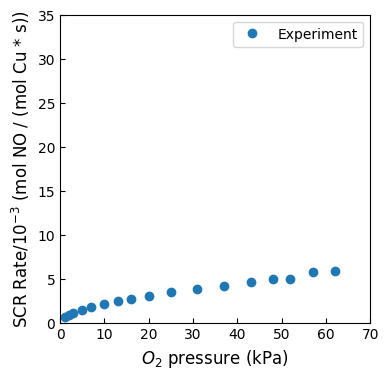

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Approximate digitized data from the right-most plot

x = np.array([
    1, 2, 3, 5, 7, 10, 13, 16,
    20, 25, 31, 37, 43, 48, 52,
    57, 62
])
y = np.array([
    0.6, 0.9, 1.1, 1.4, 1.8, 2.1, 2.4, 2.7,
    3.0, 3.5, 3.8, 4.2, 4.6, 4.9, 5.0,
    5.7, 5.9
])
plt.figure(figsize=(4,4))
plt.plot(x,y,'o',label='Experiment')
plt.xlim(0,70)
plt.ylim(0,35)
plt.xlabel(r'$O_2$ pressure (kPa)',fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))',fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.show()

# Bayesian Optimization

In [2]:
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
from zmc import Zmc

In [7]:
vol     = 1743432.3688417426   # Å³, 9x9x9 CHA supercell volume
rho_Cu  = 0.083

P_O2_exp = x                  # kPa
r_exp    = y * 1e-3            # mol NO / (mol Cu * s)

# Parameter bounds: 0 < k_red < 0.2, 0 < k_ox < 0.2, 0 < D < 60
bounds = np.array([[1e-3, 0.2 ],   # k_red
                   [1e-3, 0.2 ],   # k_ox
                   [1.0,  60.0]])  # D (Å)

def evaluate(k_red, k_ox, D):
    """Run kMC at all experimental P_O2 values and return RMSE against r_exp."""
    Ap = k_ox * vol / 1000
    rates = []
    for P_O2 in P_O2_exp:
        try:
            calc = Zmc(Ar=k_red, Ap=Ap, P_O2=float(P_O2), D=D, rho_Cu=rho_Cu, short=True)
            calc.calculate()
            calc.get_fraction()
            ss_fraction, _, _, _ = calc.get_fraction()
            ss_rate = calc.get_rate()
            rates.append(ss_rate)
        except Exception:
            rates.append(np.nan)
    rates = np.array(rates)
    if np.any(np.isnan(rates)):
        return np.inf
    return np.sqrt(np.mean((rates - r_exp) ** 2))
    

In [8]:
# Latin Hypercube Sampling: 200 initial training points
sampler  = LatinHypercube(d=3, seed=42)
lhs_unit = sampler.random(n=100)
X_lhs    = lhs_unit * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]

print(f'Running 200 LHS evaluations...')
Y_lhs = []
for i, (k_red, k_ox, D) in enumerate(X_lhs):
    obj = evaluate(k_red, k_ox, D)
    Y_lhs.append(obj)
    print(f'[{i+1:3d}/200] k_red={k_red:.4f}, k_ox={k_ox:.4f}, D={D:.2f} -> RMSE={obj:.6f}')

Y_lhs = np.array(Y_lhs)
np.save('X_lhs.npy', X_lhs)
np.save('Y_lhs.npy', Y_lhs)
print('LHS done.')

Running 200 LHS evaluations...
EWMA not converged, using mean of recorded CuII fraction: 0.23994252873563215
EWMA not converged, using mean of recorded CuII fraction: 0.23994252873563215
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
EWMA not converged, using mean of recorded CuII fraction: 0.5050156739811913
EWMA not converged, using mean of recorded CuII fraction: 0.5050156739811913
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculat

/Users/slee75/Desktop/dealumination/dealumination/kMC/zmc/outputters.py:90: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(self.t[self.cutoff :],self.rev[self.cutoff :],1)


Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
EWMA not converged, using mean of recorded CuII fraction: 0.58128078817734
EWMA not converged, using mean of recorded CuII fraction: 0.58128078817734
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
[  5/200] k_red=0.0773, k_ox=0.0232, D=34.96 -> RMSE=0.028939
Simulation sufficiently converged. Calculating averages
Simu

/Users/slee75/Desktop/dealumination/dealumination/kMC/zmc/outputters.py:90: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(self.t[self.cutoff :],self.rev[self.cutoff :],1)


Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating averages
Simulation sufficiently converged. Calculating a

KeyboardInterrupt: 

In [ ]:
# Fit GP with Matern 5/2 kernel on valid LHS points
kernel = ConstantKernel(1.0) * Matern(nu=2.5)
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                   normalize_y=True, alpha=1e-6)

valid  = np.isfinite(Y_lhs)
X_bo   = X_lhs[valid].tolist()
Y_bo   = Y_lhs[valid].tolist()
gp.fit(np.array(X_bo), np.array(Y_bo))

def neg_EI(x_new, gp, y_best):
    x_new = np.array(x_new).reshape(1, -1)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        mu, sigma = gp.predict(x_new, return_std=True)
    z  = (y_best - mu[0]) / (sigma[0] + 1e-9)
    ei = (y_best - mu[0]) * norm.cdf(z) + sigma[0] * norm.pdf(z)
    return -ei

scipy_bounds = [(b[0], b[1]) for b in bounds]
n_bo_iter    = 50

for i in range(n_bo_iter):
    y_best = min(Y_bo)

    best_x, best_val = None, np.inf
    for _ in range(50):
        x0  = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
        res = minimize(neg_EI, x0, args=(gp, y_best),
                       bounds=scipy_bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x   = res.x

    k_red, k_ox, D = best_x
    obj = evaluate(k_red, k_ox, D)
    print(f'BO [{i+1:2d}/{n_bo_iter}] k_red={k_red:.4f}, k_ox={k_ox:.4f}, D={D:.2f} -> RMSE={obj:.6f}')

    X_bo.append(best_x)
    Y_bo.append(obj)

    valid_bo = [np.isfinite(yv) for yv in Y_bo]
    gp.fit(np.array(X_bo)[valid_bo], np.array(Y_bo)[valid_bo])

np.save('X_bo.npy', np.array(X_bo))
np.save('Y_bo.npy', np.array(Y_bo))

In [ ]:
# Best parameters and plot
best_idx              = np.argmin(Y_bo)
k_red_opt, k_ox_opt, D_opt = X_bo[best_idx]
print(f'Best parameters:')
print(f'  k_red = {k_red_opt:.4f}')
print(f'  k_ox  = {k_ox_opt:.4f}')
print(f'  D     = {D_opt:.2f} A')
print(f'  RMSE  = {Y_bo[best_idx]:.6f} mol NO / (mol Cu * s)')

Ap_opt = k_ox_opt * vol / 1000
r_opt  = []
for P_O2 in P_O2_exp:
    try:
        calc = Zmc(Ar=k_red_opt, Ap=Ap_opt, P_O2=float(P_O2), D=D_opt, rho_Cu=rho_Cu, short=True)
        calc.calculate()
        calc.get_fraction()
        r_opt.append(calc.get_rate())
    except Exception:
        r_opt.append(np.nan)

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(P_O2_exp, r_exp * 1e3, 'o', label='Experiment')
plt.plot(P_O2_exp, np.array(r_opt) * 1e3, 'o', label='kMC (optimized)')
plt.xlabel(r'$O_2$ pressure (kPa)', fontsize=12)
plt.ylabel(r'SCR Rate/$10^{-3}$ (mol NO / (mol Cu * s))', fontsize=12)
plt.tick_params(direction='in')
plt.legend()
plt.tight_layout()
plt.show()